In [1]:
import os
import sys

if os.getcwd().endswith("notebooks"):
    os.chdir("..")

sys.path.append(os.path.abspath("./"))

print(f"Current work directory: {os.getcwd()}")

Current work directory: C:\Users\yyyyx\Work\OC43_machine_learning\Regression_Modeling_of_OC43_Coronavirus_Viral_Burden_from_Host_Single-cell_Transcriptomes_Using_Explainable_Machine_Learning


In [2]:
from sklearn.pipeline import Pipeline
import pandas as pd
from catboost import Pool
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scanpy as sc
import joblib

In [3]:
model = joblib.load('./Data/model/Compact_cat_after_tunning_260421.pkl')

In [4]:
df = pd.read_csv('./CSV/Bulk-seq/GSE238079_converted.csv',index_col='Gene_symbol', decimal=',')

In [5]:
df_t = df.transpose().copy()

In [6]:
df_t = (
    df_t
      .astype(str)
      .apply(lambda s: s.str.replace(',', '.', regex=False))
      .apply(pd.to_numeric, errors='coerce')
)

In [7]:
df_t.columns.name = 'Samples'

In [8]:
adata = sc.AnnData(df_t.astype(float))
adata.obs_names = df_t.index
adata.var_names = df_t.columns        

adata.var_names_make_unique()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

C:\Users\yyyyx\miniconda3\envs\ml_env\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [9]:
df_norm_log = pd.DataFrame(
    adata.X,
    index=adata.obs_names,
    columns=adata.var_names
)

In [10]:
num_features = model.feature_names_

use_cols = [c for c in num_features if c in df_norm_log.columns]

df_sub = df_norm_log[use_cols].copy()

In [11]:
y_pred = model.predict(df_sub)

In [12]:
y_pred

array([5.8796637 , 5.8049666 , 6.05640627, 6.15540467, 6.37035885,
       6.149185  ])

In [13]:
df_sub['Prediction'] = y_pred

In [14]:
df_sub['Condition'] = df_sub.index.str.split('_', n=1).str[1]

condition_order = ['Mock', 'OC43_24h', 'OC43_72h']
df_sub['Condition'] = pd.Categorical(df_sub['Condition'], categories=condition_order, ordered=True)

In [15]:
baseline = df_sub[df_sub['Condition'] == 'Mock']['Prediction'].mean()

In [16]:
df_sub['Expression_Change'] = df_sub['Prediction'] - baseline

In [17]:
conditions_order = ['Mock', 'OC43_24h', 'OC43_72h']

stats = df_sub.groupby('Condition')['Prediction'].agg(['mean', 'std']).reindex(conditions_order)
means = stats['mean'].values
stds = stats['std'].values

In [18]:
df_sub

Samples,ACTB,TPI1,FTL,RPS7,PPIA,SNHG1,SNHG7,IFRD1,HSPA5,ATP5MF,Prediction,Condition,Expression_Change
A_Mock,3.061900,1.403100,1.807968,0.587324,1.267782,0.184119,0.199275,0.260788,1.958906,0.533810,5.879664,Mock,0.037349
B_Mock,3.085583,1.416309,1.834900,0.589999,1.255459,0.176984,0.170822,0.255373,1.955856,0.578129,5.804967,Mock,-0.037349
A_OC43_24h,2.775383,1.021891,2.712533,0.484250,1.143808,0.163507,0.108463,0.446782,2.719664,0.391159,6.056406,OC43_24h,0.214091
B_OC43_24h,2.811079,0.941049,2.596500,0.443904,1.109330,0.169612,0.090739,0.467513,2.729591,0.328445,6.155405,OC43_24h,0.313090
A_OC43_72h,3.589907,0.602237,3.810532,0.520926,1.018984,0.591759,0.311481,0.628641,2.989099,0.163124,6.370359,OC43_72h,0.528044
B_OC43_72h,3.336393,0.892479,3.749298,0.522364,1.135851,0.247875,0.150588,0.744550,2.318908,0.334352,6.149185,OC43_72h,0.306870


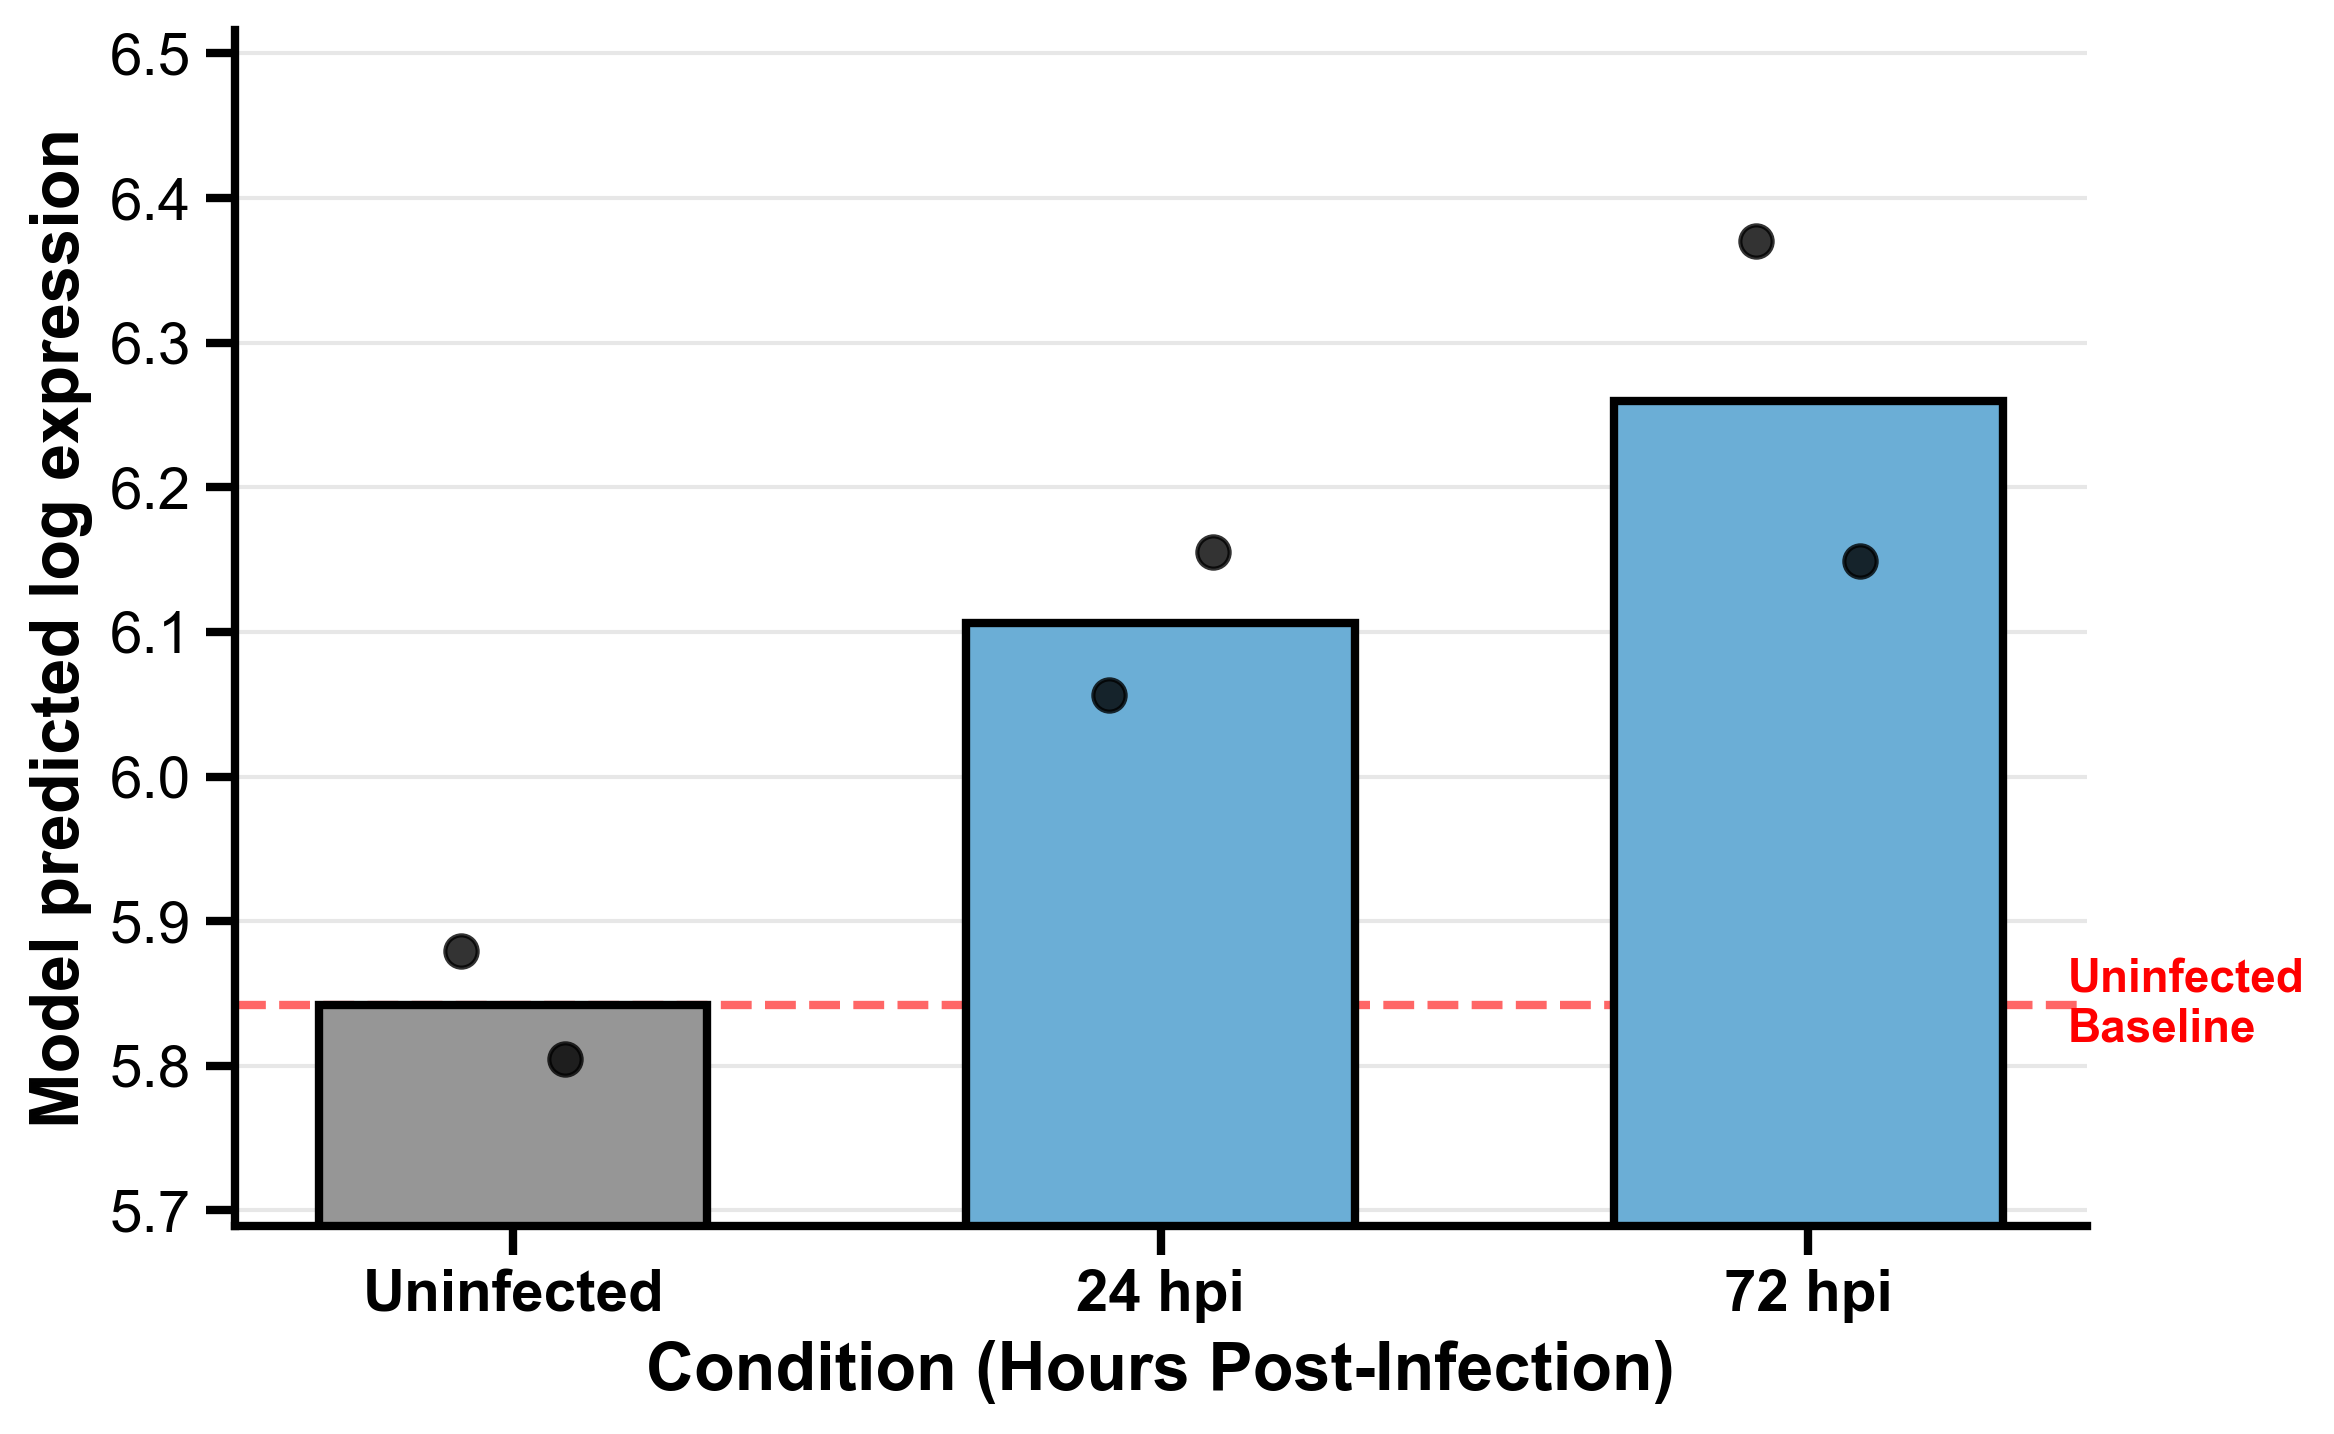

=== Condition Stat ===
               mean       std
Condition                    
Mock       5.842315  0.052819
OC43_24h   6.105905  0.070002
OC43_72h   6.259772  0.156394

Sample number by each condition:
Condition
Mock        2
OC43_24h    2
OC43_72h    2
Name: count, dtype: int64


In [19]:
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 14,
    'axes.linewidth': 2.0,
    'xtick.major.width': 2.0,
    'ytick.major.width': 2.0,
    'xtick.major.size': 7,
    'ytick.major.size': 7,
})

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

colors = ['#969696', '#6BAED6', '#6BAED6']

bars = ax.bar(range(len(conditions_order)), means, 
               color=colors, 
               edgecolor='black', 
               linewidth=2.0,
               width=0.6,
               zorder=2)

baseline_val = means[0]

for i, condition in enumerate(conditions_order):
    condition_data = df_sub[df_sub['Condition'] == condition]['Prediction']
    n_points = len(condition_data)
    if n_points == 2:
        x_positions = [i - 0.08, i + 0.08]
    else:
        x_positions = np.random.normal(i, 0.05, n_points)
    
    ax.scatter(x_positions, condition_data, 
               color='black', 
               s=60,
               alpha=0.8, 
               zorder=4)

ax.axhline(baseline_val, color='red', linestyle='--', linewidth=2.0, alpha=0.6, zorder=1)

# ==========================================
# baseline text
# ==========================================
ax.text(2.4, baseline_val,
        'Uninfected\nBaseline',         
        color='red',                  
        fontsize=11, 
        fontweight='bold',
        ha='left', va='center') 

ax.set_ylabel('Model predicted log expression', fontsize=16, fontweight='bold')
ax.set_xlabel('Condition (Hours Post-Infection)', fontsize=16, fontweight='bold')

ax.set_xticks(range(len(conditions_order)))
ax.set_xticklabels(['Uninfected', '24 hpi', '72 hpi'], fontsize=14, fontweight='bold')

ax.tick_params(axis='y', labelsize=14)

y_min = min(means - stds) - 0.1
y_max = max(means + stds) + 0.1
ax.set_ylim(y_min, y_max)

ax.yaxis.grid(True, alpha=0.3, linestyle='-', linewidth=1.0, zorder=0)
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2.0)
ax.spines['bottom'].set_linewidth(2.0)

plt.tight_layout()

plt.savefig('./Plot/OC43_Mock_24h_72h_hNECs_LargeFont_260421.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# 통계 정보 출력
print("=== Condition Stat ===")
print(stats)
print(f"\nSample number by each condition:")
print(df_sub['Condition'].value_counts().reindex(conditions_order))

In [20]:
import session_info

session_info.show()